# <center> Testing Notebook for finetuned YoloV8m Model

## Installing ByteTrack (boxmot) & fpdf2

In [1]:
!pip install boxmot -q

import boxmot
print(f'boxmot {boxmot.__version__} installed')

# for video writing + plotting
!pip install fpdf2 -q
print('fpdf2 installed (for PDF report)')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.8 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 72.5 MB/s eta 0:00:00ta 0:00:01
boxmot 16.0.11 installed
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 12.6 MB/s eta 0:00:00
fpdf2 installed (for PDF report)


## Core Tracking Function
Runs YOLO detection + ByteTrack on every frame of a video.
Outputs: annotated video + raw tracking data per frame.

In [2]:
!pip install ultralytics -q

import cv2
import numpy as np
import torch
from pathlib import Path
from ultralytics import YOLO
from boxmot import ByteTrack
from collections import defaultdict

CLASS_NAMES  = {0: 'Grasper', 1: 'L-hook'}
CLASS_COLORS = {0: (0, 255, 0), 1: (0, 200, 255)}  # BGR: green, yellow

def run_tracking(video_path, model_path, output_video_path, conf=0.40):
    """
    Run YOLO + ByteTrack on a laparoscopic video.
    Returns raw_tracks: list of dicts, one per frame with detections.
    """
    model   = YOLO(model_path)
    tracker = ByteTrack()

    cap = cv2.VideoCapture(str(video_path))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(
        str(output_video_path),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (width, height)
    )

    raw_tracks = []   # one entry per frame
    frame_idx  = 0

    print(f'Processing {total} frames at {fps:.1f}fps...')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        timestamp_sec = frame_idx / fps

        # ── YOLO detection
        results = model.predict(frame, imgsz=640, conf=conf, device=0, verbose=False)[0]

        # Build detection array for ByteTrack: [x1,y1,x2,y2,conf,class]
        dets = []
        if results.boxes is not None and len(results.boxes) > 0:
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                c   = float(box.conf[0])
                cls = int(box.cls[0])
                dets.append([x1, y1, x2, y2, c, cls])

        dets_np = np.array(dets) if dets else np.empty((0, 6))

        # ── ByteTrack update ──────────────────────────────────────────────
        # Returns: [x1,y1,x2,y2,track_id,conf,cls,idx]
        tracks = tracker.update(dets_np, frame)

        frame_data = {
            'frame_idx':     frame_idx,
            'timestamp_sec': round(timestamp_sec, 3),
            'detections':    []
        }

        annotated = frame.copy()

        if len(tracks) > 0:
            for t in tracks:
                x1, y1, x2, y2 = int(t[0]), int(t[1]), int(t[2]), int(t[3])
                track_id = int(t[4])
                conf_val = float(t[5])
                cls_id   = int(t[6])

                tool_name = CLASS_NAMES.get(cls_id, f'Class{cls_id}')
                color     = CLASS_COLORS.get(cls_id, (255, 255, 255))

                frame_data['detections'].append({
                    'track_id':  track_id,
                    'tool':      tool_name,
                    'class_id':  cls_id,
                    'conf':      round(conf_val, 3),
                    'bbox':      [x1, y1, x2, y2]
                })

                # Draw bounding box
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

                # Label: tool name + track ID + confidence
                label = f'{tool_name} #{track_id} {conf_val:.2f}'
                (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
                cv2.rectangle(annotated, (x1, y1 - lh - 8), (x1 + lw + 4, y1), color, -1)
                cv2.putText(annotated, label, (x1 + 2, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)

        # Frame counter overlay
        ts_str = f'{int(timestamp_sec//60):02d}:{timestamp_sec%60:05.2f}'
        cv2.putText(annotated, f'Frame {frame_idx}  {ts_str}',
                    (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (255, 255, 255), 2)

        raw_tracks.append(frame_data)
        out.write(annotated)
        frame_idx += 1

        if frame_idx % 100 == 0:
            print(f'  {frame_idx}/{total} frames ({100*frame_idx/total:.1f}%)')

    cap.release()
    out.release()
    print(f'\nTracking complete. Annotated video: {output_video_path}')
    return raw_tracks, fps

print('Tracking function defined')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Tracking function defined


## Running tracking on a real surgery video

In [ ]:
from pathlib import Path
import os

MODEL_PATH  = '/kaggle/input/models/rayanfarhan1902/yolov8m-cholec8kseg-finetuned/pytorch/v1/1/best.pt'

VIDEO_PATH  = '/kaggle/input/datasets/rayanfarhan1902/surgery3/surgery3.mp4' # live 5+ mins surgery video

OUTPUT_DIR  = Path('/kaggle/working/tracking_output')
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_VIDEO = OUTPUT_DIR / 'tracked_surgery.mp4'

if not Path(VIDEO_PATH).exists():
    print('⚠️  Video not found at:', VIDEO_PATH)
else:
    raw_tracks, fps = run_tracking(
        video_path=VIDEO_PATH,
        model_path=MODEL_PATH,
        output_video_path=OUTPUT_VIDEO,
        conf=0.40
    )
    print(f'   Total frames tracked: {len(raw_tracks)}')
    total_dets = sum(len(f["detections"]) for f in raw_tracks)
    print(f'   Total detections:     {total_dets}')

SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30


Processing 9734 frames at 30.0fps...
  100/9734 frames (1.0%)
  200/9734 frames (2.1%)
  300/9734 frames (3.1%)
  400/9734 frames (4.1%)
  500/9734 frames (5.1%)
  600/9734 frames (6.2%)
  700/9734 frames (7.2%)
  800/9734 frames (8.2%)
  900/9734 frames (9.2%)
  1000/9734 frames (10.3%)
  1100/9734 frames (11.3%)
  1200/9734 frames (12.3%)
  1300/9734 frames (13.4%)
  1400/9734 frames (14.4%)
  1500/9734 frames (15.4%)
  1600/9734 frames (16.4%)
  1700/9734 frames (17.5%)
  1800/9734 frames (18.5%)
  1900/9734 frames (19.5%)
  2000/9734 frames (20.5%)
  2100/9734 frames (21.6%)
  2200/9734 frames (22.6%)
  2300/9734 frames (23.6%)
  2400/9734 frames (24.7%)
  2500/9734 frames (25.7%)
  2600/9734 frames (26.7%)
  2700/9734 frames (27.7%)
  2800/9734 frames (28.8%)
  2900/9734 frames (29.8%)
  3000/9734 frames (30.8%)
  3100/9734 frames (31.8%)
  3200/9734 frames (32.9%)
  3300/9734 frames (33.9%)
  3400/9734 frames (34.9%)
  3500/9734 frames (36.0%)
  3600/9734 frames (37.0%)
  3700/97

## Building Instrument Timeline
Converts raw per-frame detections into structured appearance intervals:
`{tool, track_id, start_sec, end_sec, duration_sec, mean_conf}`

In [4]:
import pandas as pd
import json
from collections import defaultdict

def build_instrument_timeline(raw_tracks, fps, gap_tolerance_sec=1.5):
    """
    Converts per-frame tracking data into instrument appearance intervals.
    
    gap_tolerance_sec: if a tool disappears for less than this, merge the intervals.
    This handles momentary occlusion without creating many tiny fragments.
    """
    # Group detections by track_id
    track_history = defaultdict(list)

    for frame_data in raw_tracks:
        for det in frame_data['detections']:
            track_history[det['track_id']].append({
                'timestamp_sec': frame_data['timestamp_sec'],
                'frame_idx':     frame_data['frame_idx'],
                'tool':          det['tool'],
                'class_id':      det['class_id'],
                'conf':          det['conf'],
            })

    intervals = []

    for track_id, appearances in track_history.items():
        appearances.sort(key=lambda x: x['timestamp_sec'])
        tool_name = appearances[0]['tool']
        class_id  = appearances[0]['class_id']

        # Build raw intervals (consecutive frames)
        raw_intervals = []
        seg_start  = appearances[0]
        seg_frames = [appearances[0]]

        for i in range(1, len(appearances)):
            gap = appearances[i]['timestamp_sec'] - appearances[i-1]['timestamp_sec']
            if gap <= gap_tolerance_sec:
                seg_frames.append(appearances[i])
            else:
                raw_intervals.append((seg_start, seg_frames[-1], seg_frames))
                seg_start  = appearances[i]
                seg_frames = [appearances[i]]

        raw_intervals.append((seg_start, seg_frames[-1], seg_frames))

        for start_entry, end_entry, frames in raw_intervals:
            duration = end_entry['timestamp_sec'] - start_entry['timestamp_sec']
            if duration < 0.5:
                continue  # skip sub-half-second blips

            mean_conf = round(sum(f['conf'] for f in frames) / len(frames), 3)

            intervals.append({
                'track_id':    track_id,
                'tool':        tool_name,
                'class_id':    class_id,
                'start_sec':   round(start_entry['timestamp_sec'], 2),
                'end_sec':     round(end_entry['timestamp_sec'], 2),
                'duration_sec':round(duration, 2),
                'mean_conf':   mean_conf,
                'frame_count': len(frames),
            })

    # Sort by start time
    intervals.sort(key=lambda x: x['start_sec'])
    return intervals


def format_time(seconds):
    m = int(seconds // 60)
    s = seconds % 60
    return f'{m:02d}:{s:05.2f}'


# Build the timeline
timeline = build_instrument_timeline(raw_tracks, fps, gap_tolerance_sec=1.5)

# Save as CSV
df = pd.DataFrame(timeline)
csv_path = '/kaggle/working/tracking_output/instrument_timeline.csv'
df.to_csv(csv_path, index=False)

# Save as JSON
json_path = '/kaggle/working/tracking_output/instrument_timeline.json'
with open(json_path, 'w') as f:
    json.dump(timeline, f, indent=2)

print(f'✅ Timeline built: {len(timeline)} instrument appearances')
print(f'   CSV:  {csv_path}')
print(f'   JSON: {json_path}')
print()

# Print human-readable summary
print('INSTRUMENT APPEARANCE LOG')
print('-' * 65)
print(f'{"Tool":<14} {"Track ID":<10} {"Start":<10} {"End":<10} {"Duration":<12} {"Conf"}')
print('-' * 65)
for entry in timeline:
    print(f'{entry["tool"]:<14} #{entry["track_id"]:<9} '
          f'{format_time(entry["start_sec"]):<10} '
          f'{format_time(entry["end_sec"]):<10} '
          f'{entry["duration_sec"]:>6.1f}s      '
          f'{entry["mean_conf"]:.3f}')

✅ Timeline built: 79 instrument appearances
   CSV:  /kaggle/working/tracking_output/instrument_timeline.csv
   JSON: /kaggle/working/tracking_output/instrument_timeline.json

INSTRUMENT APPEARANCE LOG
-----------------------------------------------------------------
Tool           Track ID   Start      End        Duration     Conf
-----------------------------------------------------------------
Grasper        #2         00:23.89   00:25.23      1.3s      0.517
Grasper        #23        00:53.72   00:54.76      1.0s      0.531
Grasper        #28        00:58.73   01:01.96      3.2s      0.730
Grasper        #36        01:01.76   01:04.73      3.0s      0.720
Grasper        #39        01:03.53   01:04.06      0.5s      0.641
Grasper        #40        01:04.93   01:06.40      1.5s      0.754
Grasper        #45        01:06.57   01:28.39     21.8s      0.832
Grasper        #47        01:06.63   01:11.61      5.0s      0.871
Grasper        #48        01:07.23   01:14.24      7.0s      0.6

## Summary Statistics
Per-tool totals: time in frame, appearance count, mean confidence.

In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/working/tracking_output/instrument_timeline.csv')

total_video_sec = raw_tracks[-1]['timestamp_sec'] if raw_tracks else 0

print('='*55)
print('  SURGICAL INSTRUMENT SUMMARY')
print('='*55)
print(f'  Video duration:   {format_time(total_video_sec)}')
print(f'  Total frames:     {len(raw_tracks)}')
print(f'  Total appearances:{len(df)}')
print()

summary = df.groupby('tool').agg(
    total_time_sec  = ('duration_sec', 'sum'),
    appearances     = ('track_id', 'count'),
    mean_confidence = ('mean_conf', 'mean'),
    longest_sec     = ('duration_sec', 'max'),
).round(2)

summary['pct_of_video'] = (summary['total_time_sec'] / total_video_sec * 100).round(1)
summary['mean_confidence'] = summary['mean_confidence'].round(3)

print(summary.to_string())
print()

# Save summary
summary.to_csv('/kaggle/working/tracking_output/instrument_summary.csv')
print('✅ Summary saved to /kaggle/working/tracking_output/instrument_summary.csv')

  SURGICAL INSTRUMENT SUMMARY
  Video duration:   05:24.76
  Total frames:     9734
  Total appearances:79

         total_time_sec  appearances  mean_confidence  longest_sec  pct_of_video
tool                                                                            
Grasper          261.01           72             0.71        25.43          80.4
L-hook            80.15            7             0.70        38.24          24.7

✅ Summary saved to /kaggle/working/tracking_output/instrument_summary.csv


## Gantt Timeline Chart
Visualises when each tool was active, colour-coded by tool type.

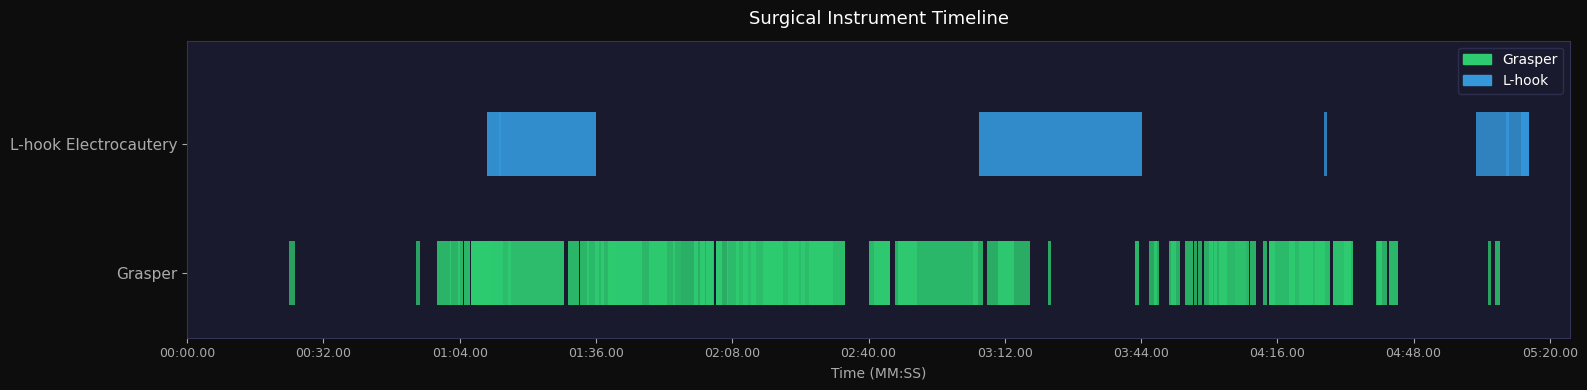

✅ Timeline chart saved: /kaggle/working/tracking_output/instrument_timeline_chart.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/working/tracking_output/instrument_timeline.csv')

TOOL_COLORS = {'Grasper': '#2ecc71', 'L-hook': '#3498db'}
TOOL_Y      = {'Grasper': 1,         'L-hook': 2}
YTICKLABELS = {1: 'Grasper', 2: 'L-hook Electrocautery'}

total_video_sec = raw_tracks[-1]['timestamp_sec'] if raw_tracks else df['end_sec'].max()

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a2e')

for _, row in df.iterrows():
    tool  = row['tool']
    y     = TOOL_Y.get(tool, 3)
    color = TOOL_COLORS.get(tool, '#e74c3c')
    alpha = min(1.0, 0.5 + row['mean_conf'] * 0.5)  # higher conf = more opaque

    ax.barh(
        y, row['duration_sec'],
        left=row['start_sec'],
        height=0.5,
        color=color,
        alpha=alpha,
        edgecolor='none',
    )

# X axis: time in MM:SS
tick_interval = max(10, int(total_video_sec / 10))
xticks = np.arange(0, total_video_sec + tick_interval, tick_interval)
ax.set_xticks(xticks)
ax.set_xticklabels([format_time(t) for t in xticks],
                    color='#aaaaaa', fontsize=9)

ax.set_yticks(list(TOOL_Y.values()))
ax.set_yticklabels([YTICKLABELS[y] for y in TOOL_Y.values()],
                    color='white', fontsize=11)
ax.set_xlim(0, total_video_sec)
ax.set_ylim(0.5, 2.8)
ax.set_xlabel('Time (MM:SS)', color='#aaaaaa', fontsize=10)
ax.set_title('Surgical Instrument Timeline', color='white', fontsize=13, pad=12)
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Legend
legend_patches = [
    mpatches.Patch(color=color, label=tool)
    for tool, color in TOOL_COLORS.items()
]
ax.legend(handles=legend_patches, loc='upper right',
          facecolor='#1a1a2e', edgecolor='#333355',
          labelcolor='white', fontsize=10)

plt.tight_layout()
chart_path = '/kaggle/working/tracking_output/instrument_timeline_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Timeline chart saved: {chart_path}')

## Generating PDF Surgical Report

In [7]:
from fpdf import FPDF
import pandas as pd
from datetime import datetime

df_timeline = pd.read_csv('/kaggle/working/tracking_output/instrument_timeline.csv')
df_summary  = pd.read_csv('/kaggle/working/tracking_output/instrument_summary.csv')
total_sec   = raw_tracks[-1]['timestamp_sec'] if raw_tracks else 0

class SurgicalReport(FPDF):
    def header(self):
        self.set_fill_color(15, 15, 46)
        self.rect(0, 0, 210, 28, 'F')
        self.set_text_color(255, 255, 255)
        self.set_font('Helvetica', 'B', 16)
        self.set_xy(10, 8)
        self.cell(0, 10, 'Surgical Intelligence Report', ln=True)
        self.set_font('Helvetica', '', 9)
        self.set_xy(10, 18)
        self.cell(0, 6, f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}  |  Model: YOLOv8m + ByteTrack')
        self.set_text_color(0, 0, 0)
        self.ln(18)

    def footer(self):
        self.set_y(-12)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(150, 150, 150)
        self.cell(0, 10, f'Page {self.page_no()}  |  For research and training use only', align='C')

pdf = SurgicalReport()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

# ── Section 1: Video summary ──────────────────────────────────────────────────
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '1. Procedure Summary', ln=True)
pdf.set_draw_color(26, 86, 160)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

pdf.set_font('Helvetica', '', 11)
pdf.set_text_color(0, 0, 0)
stats = [
    ('Procedure type',     'Laparoscopic Cholecystectomy'),
    ('Video duration',     format_time(total_sec)),
    ('Total frames',       str(len(raw_tracks))),
    ('Instruments tracked',str(df_timeline['tool'].nunique())),
    ('Total appearances',  str(len(df_timeline))),
]
for label, value in stats:
    pdf.set_font('Helvetica', 'B', 10)
    pdf.cell(60, 7, label + ':', border=0)
    pdf.set_font('Helvetica', '', 10)
    pdf.cell(0, 7, value, ln=True)

pdf.ln(6)

# ── Section 2: Per-instrument stats table ─────────────────────────────────────
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '2. Instrument Statistics', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

# Table header
headers = ['Instrument', 'Total Time', '% of Video', 'Appearances', 'Mean Conf']
col_w   = [55, 35, 32, 35, 33]
pdf.set_fill_color(26, 86, 160)
pdf.set_text_color(255, 255, 255)
pdf.set_font('Helvetica', 'B', 10)
for h, w in zip(headers, col_w):
    pdf.cell(w, 8, h, border=1, fill=True, align='C')
pdf.ln()

pdf.set_text_color(0, 0, 0)
fill = False
for _, row in df_summary.iterrows():
    pdf.set_fill_color(235, 242, 252) if fill else pdf.set_fill_color(255, 255, 255)
    pdf.set_font('Helvetica', '', 10)
    vals = [
        str(row.get('tool', row.name)),
        format_time(float(row['total_time_sec'])),
        f"{row['pct_of_video']:.1f}%",
        str(int(row['appearances'])),
        f"{row['mean_confidence']:.3f}",
    ]
    for v, w in zip(vals, col_w):
        pdf.cell(w, 7, v, border=1, fill=True, align='C')
    pdf.ln()
    fill = not fill

pdf.ln(8)

# ── Section 3: Timeline chart ─────────────────────────────────────────────────
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '3. Instrument Timeline', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

chart_path = '/kaggle/working/tracking_output/instrument_timeline_chart.png'
if Path(chart_path).exists():
    pdf.image(chart_path, x=10, w=190)

pdf.ln(6)

# ── Section 4: Detailed appearance log ───────────────────────────────────────
pdf.add_page()
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '4. Detailed Appearance Log', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

log_headers = ['Tool', 'Track ID', 'Start', 'End', 'Duration', 'Confidence']
log_widths  = [40, 25, 30, 30, 30, 35]

pdf.set_fill_color(26, 86, 160)
pdf.set_text_color(255, 255, 255)
pdf.set_font('Helvetica', 'B', 9)
for h, w in zip(log_headers, log_widths):
    pdf.cell(w, 7, h, border=1, fill=True, align='C')
pdf.ln()

pdf.set_text_color(0, 0, 0)
fill = False
for entry in timeline:
    pdf.set_fill_color(235, 242, 252) if fill else pdf.set_fill_color(255, 255, 255)
    pdf.set_font('Helvetica', '', 9)
    row_vals = [
        entry['tool'],
        f"#{entry['track_id']}",
        format_time(entry['start_sec']),
        format_time(entry['end_sec']),
        f"{entry['duration_sec']:.1f}s",
        f"{entry['mean_conf']:.3f}",
    ]
    for v, w in zip(row_vals, log_widths):
        pdf.cell(w, 6, v, border=1, fill=True, align='C')
    pdf.ln()
    fill = not fill

# Save PDF
pdf_path = '/kaggle/working/tracking_output/surgical_report.pdf'
pdf.output(pdf_path)
print(f'✅ PDF report saved: {pdf_path}')

✅ PDF report saved: /kaggle/working/tracking_output/surgical_report.pdf


/tmp/ipykernel_55/140427074.py:16: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'Surgical Intelligence Report', ln=True)
/tmp/ipykernel_55/140427074.py:36: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, '1. Procedure Summary', ln=True)
/tmp/ipykernel_55/140427074.py:54: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 7, value, ln=True)
/tmp/ipykernel_55/140427074.py:61: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, '2. Instrument Statistics', ln=True)
/tmp/ipykernel_55/140427074.py:97: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos